# SMA 50/200 Crossover Backtest on SPY

**Strategy:** Go long when 50-day simple moving average crosses above the 200-day SMA (golden cross). Exit when it crosses back below (death cross).

**Universe:** SPY (S&P 500 ETF), last 5 years of daily data.

**Benchmark:** Buy-and-hold SPY.

**Metrics:** Total return, annualized return, Sharpe ratio, max drawdown.

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

plt.style.use('default')
pd.options.display.float_format = '{:.4f}'.format

## 1. Download data

In [2]:
TICKER = 'SPY'
START = '2021-01-01'
END = '2026-05-08'

raw = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)
df = raw[['Close']].copy()
df.columns = ['close']
print(f'Rows: {len(df)}  Range: {df.index.min().date()} to {df.index.max().date()}')
df.head()

Rows: 1342  Range: 2021-01-04 to 2026-05-07


,close
Date,
2021-01-04,343.3191
2021-01-05,345.6837
2021-01-06,347.7503
2021-01-07,352.9170
2021-01-08,354.9279


## 2. Compute SMAs and signals

In [3]:
df['sma_50'] = df['close'].rolling(50).mean()
df['sma_200'] = df['close'].rolling(200).mean()

# Position: 1 when sma_50 > sma_200, else 0. Shift(1) to avoid lookahead bias.
df['position'] = (df['sma_50'] > df['sma_200']).astype(int).shift(1).fillna(0)

# Mark crossover events
df['signal'] = df['position'].diff()
entries = df[df['signal'] == 1]
exits = df[df['signal'] == -1]
print(f'Entries (golden cross): {len(entries)}')
print(f'Exits  (death cross):  {len(exits)}')
df.tail()

Entries (golden cross): 3
Exits  (death cross):  2


,close,sma_50,sma_200,position,signal
Date,,,,,
2026-05-01,720.6500,679.4779,667.9377,1.0000,0.0000
2026-05-04,718.0100,680.0870,668.4139,1.0000,0.0000
2026-05-05,723.7700,680.9518,668.9213,1.0000,0.0000
2026-05-06,733.8300,681.9188,669.4730,1.0000,0.0000
2026-05-07,731.5800,682.7252,670.0130,1.0000,0.0000


## 3. Backtest returns

In [4]:
df['ret'] = df['close'].pct_change().fillna(0)
df['strat_ret'] = df['ret'] * df['position']

df['equity_buyhold'] = (1 + df['ret']).cumprod()
df['equity_strat'] = (1 + df['strat_ret']).cumprod()
df[['equity_buyhold', 'equity_strat']].tail()

,equity_buyhold,equity_strat
Date,,
2026-05-01,2.0991,1.5475
2026-05-04,2.0914,1.5418
2026-05-05,2.1082,1.5542
2026-05-06,2.1375,1.5758
2026-05-07,2.1309,1.5710


## 4. Performance metrics

In [5]:
TRADING_DAYS = 252

def metrics(returns, equity, label):
    total_return = equity.iloc[-1] - 1
    years = len(returns) / TRADING_DAYS
    cagr = equity.iloc[-1] ** (1 / years) - 1
    sharpe = (returns.mean() / returns.std()) * np.sqrt(TRADING_DAYS) if returns.std() > 0 else 0
    dd = (equity / equity.cummax() - 1).min()
    return {
        'strategy': label,
        'total_return': total_return,
        'cagr': cagr,
        'sharpe': sharpe,
        'max_drawdown': dd,
    }

summary = pd.DataFrame([
    metrics(df['ret'], df['equity_buyhold'], 'Buy & Hold SPY'),
    metrics(df['strat_ret'], df['equity_strat'], 'SMA 50/200 Crossover'),
])
summary

,strategy,total_return,cagr,sharpe,max_drawdown
0,Buy & Hold SPY,1.1309,0.1527,0.9244,-0.2450
1,SMA 50/200 Crossover,0.5710,0.0885,0.7376,-0.1876


## 5. Plot price + SMAs with entry/exit markers

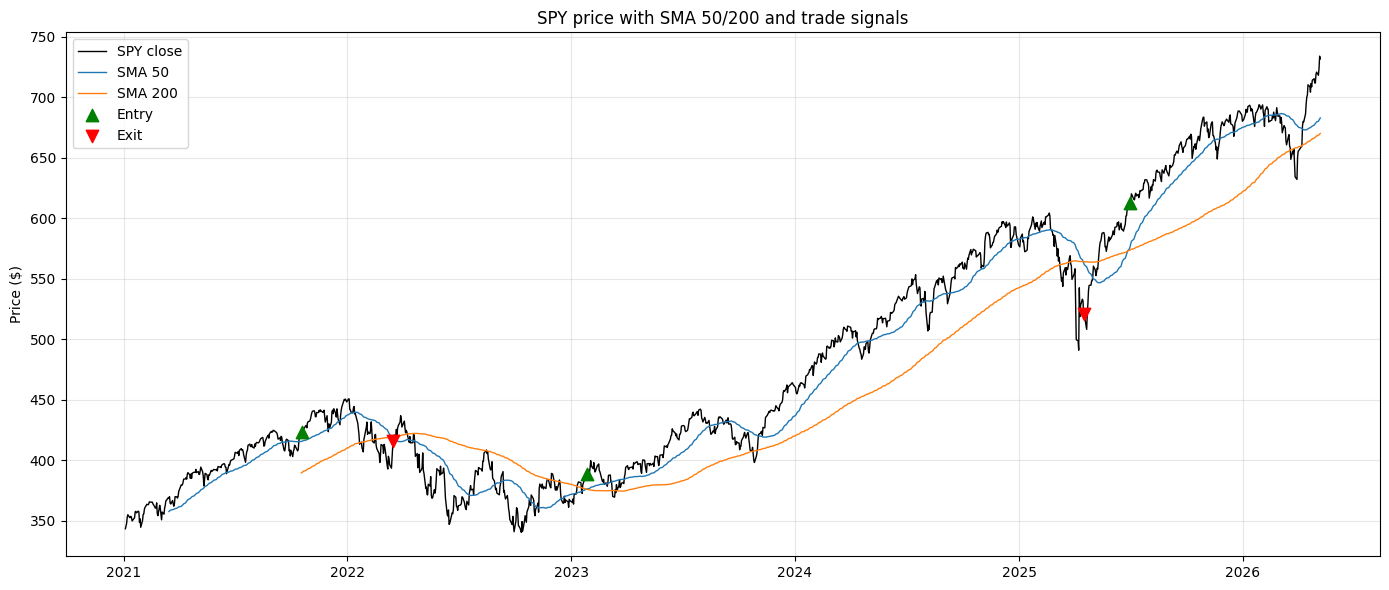

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['close'], label='SPY close', color='black', linewidth=1)
ax.plot(df.index, df['sma_50'], label='SMA 50', color='tab:blue', linewidth=1)
ax.plot(df.index, df['sma_200'], label='SMA 200', color='tab:orange', linewidth=1)
ax.scatter(entries.index, entries['close'], marker='^', color='green', s=80, label='Entry', zorder=5)
ax.scatter(exits.index, exits['close'], marker='v', color='red', s=80, label='Exit', zorder=5)
ax.set_title('SPY price with SMA 50/200 and trade signals')
ax.set_ylabel('Price ($)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Equity curve: strategy vs buy-and-hold

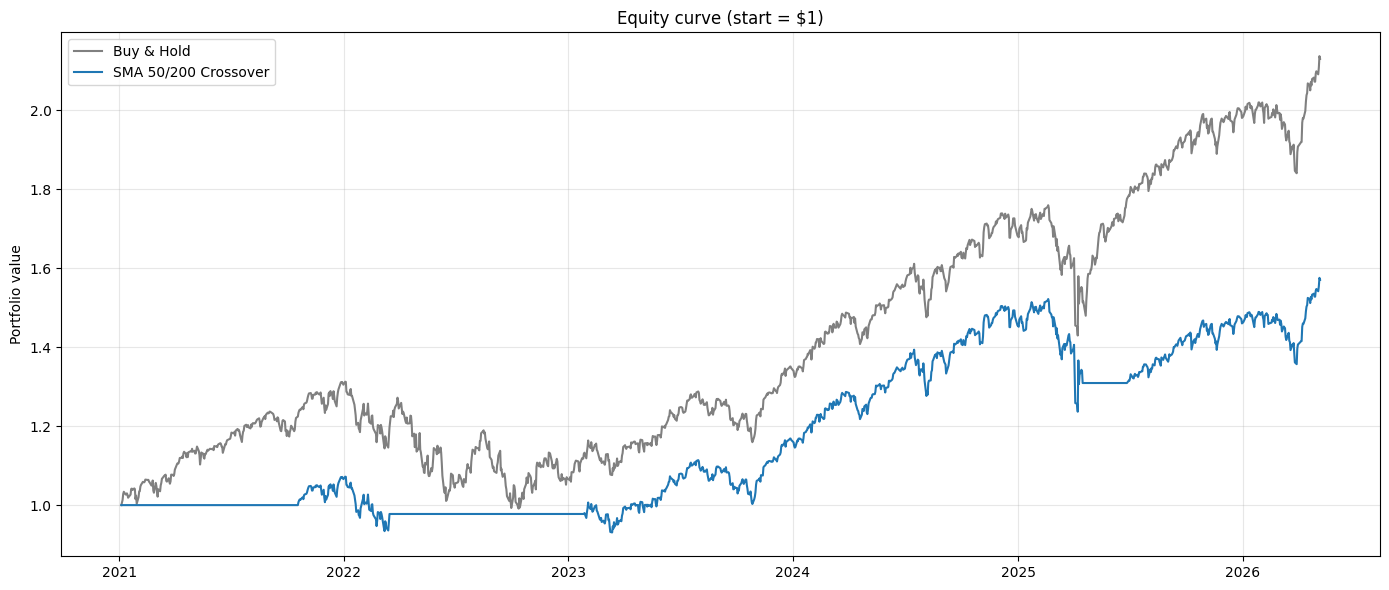

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['equity_buyhold'], label='Buy & Hold', color='gray', linewidth=1.5)
ax.plot(df.index, df['equity_strat'], label='SMA 50/200 Crossover', color='tab:blue', linewidth=1.5)
ax.set_title('Equity curve (start = $1)')
ax.set_ylabel('Portfolio value')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Drawdown comparison

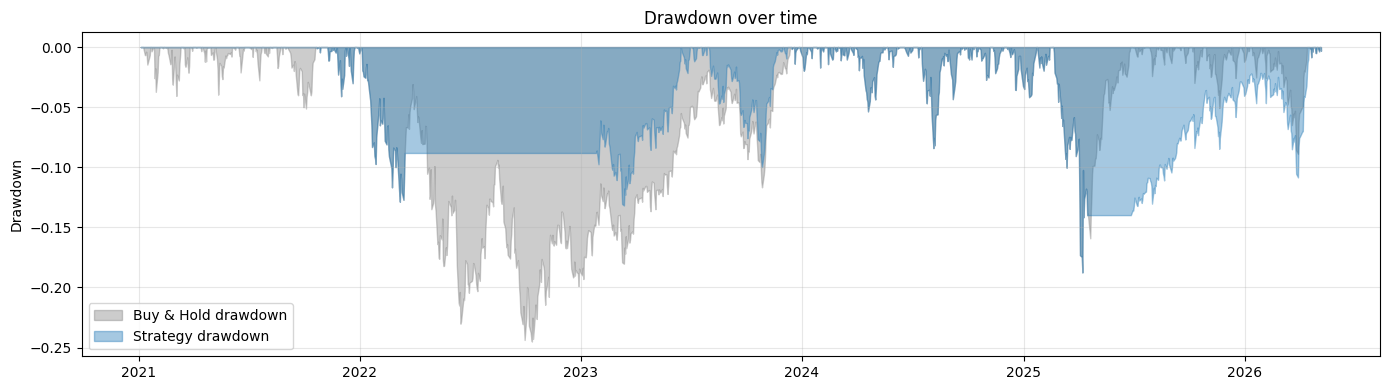

In [8]:
dd_bh = df['equity_buyhold'] / df['equity_buyhold'].cummax() - 1
dd_st = df['equity_strat'] / df['equity_strat'].cummax() - 1

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(df.index, dd_bh, 0, color='gray', alpha=0.4, label='Buy & Hold drawdown')
ax.fill_between(df.index, dd_st, 0, color='tab:blue', alpha=0.4, label='Strategy drawdown')
ax.set_title('Drawdown over time')
ax.set_ylabel('Drawdown')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Notes & caveats

- **No transaction costs / slippage** modeled. Real-world results would be worse.
- **Lookahead bias avoided** by shifting position by 1 day (we trade on the next bar after the signal).
- **5-year window** captures one regime; results are not robust evidence the strategy works long-term.
- **Position sizing is binary** (100% in or 100% cash). No leverage, no risk targeting.
- Cash earns 0% in this backtest. In reality T-bills would add to the strategy return during cash periods.

## Next experiments

1. Add transaction cost (e.g., 5 bps round-trip) and re-run.
2. Sweep SMA window pairs (10/50, 20/100, 50/200, 100/300) — heatmap of Sharpe.
3. Test on QQQ, IWM, sector ETFs — does the edge hold cross-asset?
4. Add a regime filter (e.g., only long when VIX < 25).